In [ ]:
# Download data from Zenodo (skip if already downloaded)
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'scripts'))
from download_data import download_all
from config import DATA_ROOT

if not os.path.exists(os.path.join(DATA_ROOT, 'summary_stats.h5')):
    download_all()
else:
    print(f'Data already present at {DATA_ROOT}')

# Final Plots - Eccentricity Distribution and Velocity Dispersion CDF

This notebook creates a two-panel figure showing:
1. **Left panel**: Eccentricity distributions p(e|σ) for different velocity dispersions σ
2. **Right panel**: Survival function of the velocity dispersion posterior

Data is loaded from `ecc_pop.pkl`.

---

**NOTE:** The eccentricity distribution function uses the corrected formula:
```
σ_rel = √(2/3) × σ_3D = √2 × σ
```
where σ is the 1D velocity dispersion, and σ_rel is the 
relative velocity dispersion between two objects drawn from the same Maxwellian.

**IMPORTANT:** The checkpoint data must be regenerated using the corrected `ecc_dist_cole_checkpoint.ipynb` 
notebook. All grids and posteriors are stored in terms of 1D sigma.

In [1]:
import os
import sys
sys.path.insert(0, os.path.join(os.path.dirname("__file__"), "..", "scripts"))

import numpy as np
import matplotlib.pyplot as plt
import dill
import math
from scipy.signal import savgol_filter
from config import DATA_ROOT

# Physical constants (CGS)
GMsun = 1.32712440018e26  # G * M_sun in cm^3/s^2
cspeed = 2.99792458e10    # speed of light in cm/s
forbref = 10.0            # reference orbital frequency in Hz

# Load checkpoint data (generated by ecc_dist_cole_checkpoint.ipynb)
checkpoint_path = os.path.join(DATA_ROOT, "ecc_pop.pkl")
with open(checkpoint_path, 'rb') as f:
    checkpoint_data = dill.load(f)

# Extract all needed variables
sigma_grid = checkpoint_data['sigma_grid']
sigma_min = checkpoint_data['sigma_min']
sigma_max = checkpoint_data['sigma_max']

log_L_events = checkpoint_data['log_L_events']
log_L_total = np.zeros_like(sigma_grid)
for name in log_L_events:
    log_L_total += log_L_events[name]
log_L_smooth = savgol_filter(log_L_total, window_length=7, polyorder=3)
log_L_smooth -= log_L_smooth.max()
p_sigma_global_all_d = np.exp(log_L_smooth)
p_sigma_global_all_d /= np.trapezoid(p_sigma_global_all_d, sigma_grid)

# Branching fraction variables
B_grid = checkpoint_data['B_grid']
posterior_B = checkpoint_data['posterior_B']
log_posterior_B = checkpoint_data['log_posterior_B']

# Log-normal fit parameters and PDFs
gc_lognormal_params = checkpoint_data['gc_lognormal_params']
nsc_lognormal_params = checkpoint_data['nsc_lognormal_params']
p_gc_log10sigma = checkpoint_data['p_gc_log10sigma']
p_nsc_log10sigma = checkpoint_data['p_nsc_log10sigma']

# Raw 1D dispersion data for histograms
gc_sigma_1d_kms = checkpoint_data['gc_sigma_1d_kms']
nsc_sigma_1d_kms = checkpoint_data['nsc_sigma_1d_kms']

print(f"Loaded checkpoint from: {checkpoint_data['saved_at']}")
print(f"Keys available: {list(checkpoint_data.keys())}")



Loaded checkpoint from: 2026-03-02T15:46:42.095405
Keys available: ['log_L_events', 'p_sigma_global_all_d', 'sigma_grid', 'sigma_min', 'sigma_max', 'nsigma', 'event_samples', 'B_grid', 'log_posterior_B', 'posterior_B', 'gc_lognormal_params', 'nsc_lognormal_params', 'p_gc_log10sigma', 'p_nsc_log10sigma', 'gc_sigma_1d_kms', 'nsc_sigma_1d_kms', 'saved_at']


In [2]:
from formatting import initialize_latex, COLORS
initialize_latex()

In [3]:
# ============================================================
# Function to compute p(e | sigma) for a given velocity dispersion
# ============================================================
# Uses Monte Carlo sampling following Cole & Toonen (2023) prescription

# Eccentricity bounds
log10_e_min, log10_e_max = -11.0, -0.1 
e_min, e_max = 10 ** log10_e_min, 10 ** log10_e_max
ne = 200  # Number of bins (increased for smoother histograms)

# Default sampling parameters
Niter = 40   # Number of velocity draws
Nrp = 200    # Number of pericenter bins per velocity

# Random number generator
rng = np.random.default_rng(42)

def p_e_given_sigma_Mtot_mu(sigma, Mtot, mu, Niter_local=None, Nrp_local=None):
    """
    Vectorized Monte Carlo approximation to p(e | sigma, M, mu).
    
    Parameters
    ----------
    sigma : float
        1D velocity dispersion in cm/s
    Mtot : float
        Total mass in solar masses
    mu : float
        Reduced mass in solar masses
    Niter_local : int, optional
        Number of velocity draws (default: global Niter)
    Nrp_local : int, optional
        Number of pericenter bins per velocity (default: global Nrp)
    
    Returns
    -------
    eccs : ndarray
        Eccentricity bin centers (log-spaced)
    pdf : ndarray
        Normalized PDF values at eccs
    """
    Niter_use = Niter if Niter_local is None else int(Niter_local)
    Nrp_use = Nrp if Nrp_local is None else int(Nrp_local)

    # Convert 1D velocity dispersion to 3D: sigma_3D = sqrt(3) * sigma
    s3d = math.sqrt(3.0) * float(sigma)
    # sigma_rel = sqrt(2/3) * sigma_3D = sqrt(2/3) * sqrt(3) * sigma = sqrt(2) * sigma
    sigma_rel = math.sqrt(2.0) * s3d
    atarg = (GMsun * Mtot / (4.0 * math.pi**2 * forbref**2))**(1.0/3.0)

    # Batch velocity sampling with accept-reject
    e_samples_list = []
    n_accepted = 0
    max_attempts = 50
    attempt = 0
    
    while n_accepted < Niter_use and attempt < max_attempts:
        attempt += 1
        batch_size = max(2 * (Niter_use - n_accepted), 100)
        
        # Draw |N(0,1)| samples
        x_batch = np.abs(rng.standard_normal(batch_size))
        y_batch = rng.random(batch_size)
        
        # Accept-reject: keep where y < x^(3/7)
        accept_mask = y_batch < np.power(x_batch, 3.0/7.0)
        x_accepted = x_batch[accept_mask]
        
        if len(x_accepted) == 0:
            continue
        
        n_needed = Niter_use - n_accepted
        x_use = x_accepted[:n_needed]
        n_accepted += len(x_use)
        
        # Compute vinf for accepted samples
        vinf = x_use * sigma_rel
        
        # Compute rpmax for each velocity
        coeff = (85.0 * math.pi / (6.0 * math.sqrt(2.0)))**(2.0/7.0)
        coeff *= GMsun * (mu * Mtot**2.5)**(2.0/7.0)
        coeff /= cspeed**(10.0/7.0)
        rpmax = coeff / np.power(vinf, 4.0/7.0)
        
        # Vectorized pericenter loop
        j_idx = np.arange(Nrp_use) + 0.5
        drp = rpmax / Nrp_use
        rp = np.outer(drp, j_idx)
        C = 1.76 * rp  # Peters constant
        
        # Vectorized bisection for eccentricity
        emin_arr = np.zeros_like(rp)
        emax_arr = np.ones_like(rp)
        
        for _ in range(30):
            emid = 0.5 * (emin_arr + emax_arr)
            emid_safe = np.maximum(emid, 1e-15)
            
            a_val = C / (
                np.power(emid_safe, -12.0/19.0)
                * (1.0 - emid * emid)
                * np.power(1.0 + 121.0 * emid * emid / 304.0, -870.0/2299.0)
            )
            
            too_high = a_val > atarg
            emax_arr = np.where(too_high, emid, emax_arr)
            emin_arr = np.where(~too_high, emid, emin_arr)
        
        e_final = 0.5 * (emin_arr + emax_arr)
        valid_mask = (e_final >= 0.0) & (e_final <= 1.0)
        e_samples_list.append(e_final[valid_mask].ravel())
    
    # Combine all samples
    if e_samples_list:
        e_arr = np.concatenate(e_samples_list)
    else:
        e_arr = np.array([])
    
    # Filter to [e_min, e_max]
    e_arr = e_arr[(e_arr >= e_min) & (e_arr <= e_max)]
    
    # Histogram in LOG-SPACE
    log_edges = np.linspace(np.log10(e_min), np.log10(e_max), ne + 1)
    edges = 10 ** log_edges
    
    counts, _ = np.histogram(e_arr, bins=edges)
    bin_widths = np.diff(edges)
    total = np.sum(counts)
    if total > 0:
        pdf = counts / (total * bin_widths)
    else:
        pdf = np.zeros(ne)
    
    eccs = np.sqrt(edges[:-1] * edges[1:])
    return eccs, pdf, edges  # Also return edges for filled histograms

print("Eccentricity distribution function defined (sigma_rel = sqrt(2) * sigma).")

Eccentricity distribution function defined (sigma_rel = sqrt(2) * sigma).


Computing eccentricity distributions for different sigma values...
  sigma = 5 km/s...
  sigma = 10 km/s...
  sigma = 30 km/s...
  sigma = 100 km/s...
  sigma = 300 km/s...
Done!
Global sigma posterior (1D):
  Median:          9.6 km/s
  90% CI:          [2.9, 24.3] km/s
  1-sigma upper:   17.5 km/s

Mixture hyper model (1D):
  Median:          6.3 km/s
  90% CI:          [1.6, 78.1] km/s

Drawn 50 PPD samples from B posterior (B range: [0.343, 0.985])

Branching fraction beta = 1 - B:
  Median: 0.129,  90% CI: [0.010, 0.494]


/tmp/ipykernel_2902928/2835919927.py:233: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


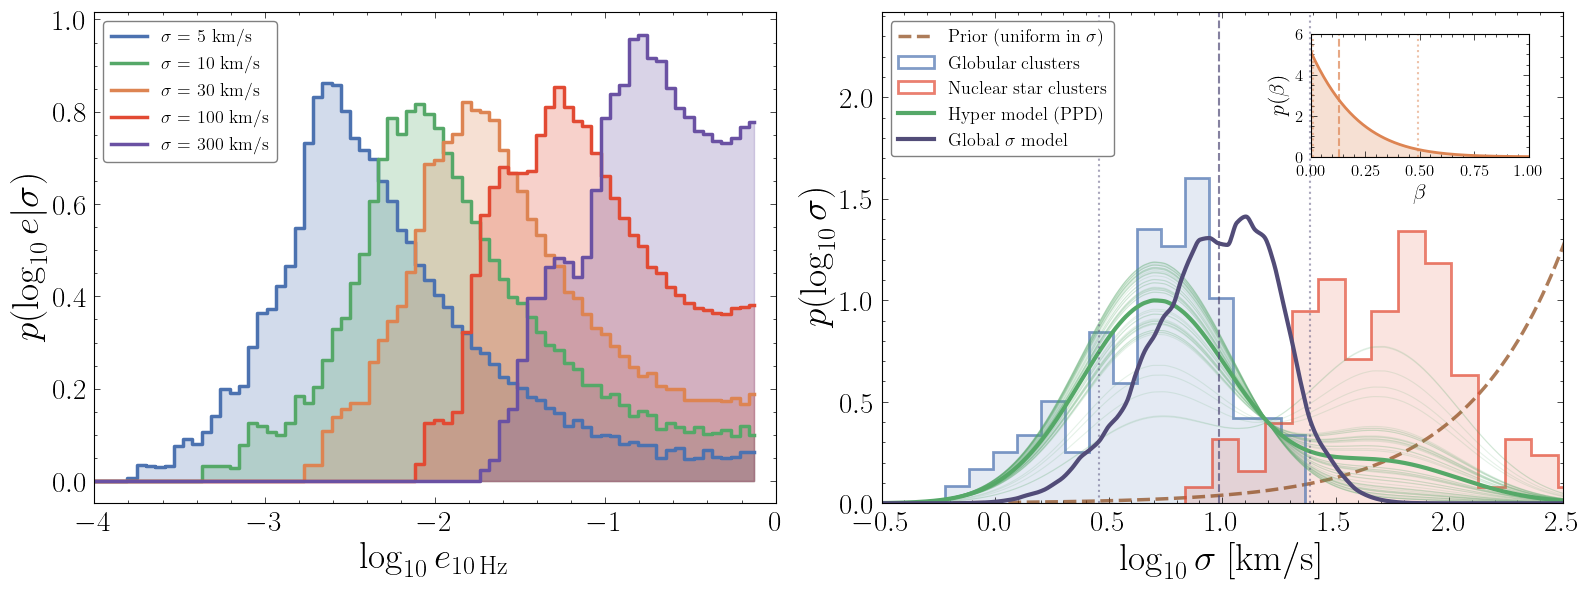


Figure saved as '../figures/ecc_sigma_combined_plot.pdf' and '../figures/ecc_sigma_combined_plot.png'


In [4]:
# ============================================================
# Compute eccentricity distributions for different sigma values
# ============================================================
from scipy.interpolate import PchipInterpolator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Representative sigma values (1D velocity dispersion, in km/s) spanning GC to NSC environments
sigma_values_km_s = [5, 10, 30, 100, 300]
sigma_values_cm_s = [s * 1e5 for s in sigma_values_km_s]

# Reference masses (typical for GW capture events)
M1, M2 = 30.0, 10.0  # Solar masses
Mtot = M1 + M2
mu = M1 * M2 / Mtot

# Color palette for different sigmas (using COLORS scheme)
ecc_colors = [COLORS['blue'], COLORS['green'], COLORS['orange'], COLORS['red'], COLORS['purple']]

print("Computing eccentricity distributions for different sigma values...")
ecc_distributions = {}
for sig_km_s, sig_cm_s in zip(sigma_values_km_s, sigma_values_cm_s):
    print(f"  sigma = {sig_km_s} km/s...")
    eccs, pdf, edges = p_e_given_sigma_Mtot_mu(sig_cm_s, Mtot, mu)
    ecc_distributions[sig_km_s] = (eccs, pdf, edges)
print("Done!")

# ============================================================
# Helper functions
# ============================================================

def pdf_to_cdf(pdf, grid):
    """Convert a PDF to a CDF using trapezoidal integration."""
    cdf = np.zeros_like(pdf)
    cdf[1:] = np.cumsum(0.5 * (pdf[:-1] + pdf[1:]) * np.diff(grid))
    cdf /= cdf[-1]
    return cdf

def pdf_to_survival(pdf, grid):
    """Convert a PDF to a survival function (1 - CDF)."""
    return 1.0 - pdf_to_cdf(pdf, grid)

# ============================================================
# Compute credible intervals for global sigma posterior
# ============================================================
sigma_km_s_grid = sigma_grid / 1e5
log10_sigma_km_s = np.log10(sigma_km_s_grid)
cdf_global = pdf_to_cdf(p_sigma_global_all_d, sigma_grid)

# Percentiles in sigma (km/s)
sigma_median = np.interp(0.50, cdf_global, sigma_km_s_grid)
sigma_05 = np.interp(0.05, cdf_global, sigma_km_s_grid)
sigma_95 = np.interp(0.95, cdf_global, sigma_km_s_grid)
sigma_84 = np.interp(0.84, cdf_global, sigma_km_s_grid)

print(f"Global sigma posterior (1D):")
print(f"  Median:          {sigma_median:.1f} km/s")
print(f"  90% CI:          [{sigma_05:.1f}, {sigma_95:.1f}] km/s")
print(f"  1-sigma upper:   {sigma_84:.1f} km/s")

# ============================================================
# Compute credible intervals for mixture hyper model
# ============================================================
B_mean = np.trapezoid(B_grid * posterior_B, B_grid)
ppd_log10 = B_mean * p_gc_log10sigma + (1 - B_mean) * p_nsc_log10sigma

# CDF of the mixture model PPD (defined in log10 sigma space)
cdf_mix = pdf_to_cdf(ppd_log10, log10_sigma_km_s)

# Percentiles in log10(sigma / [km/s]), then convert to km/s
mix_median_log10 = np.interp(0.50, cdf_mix, log10_sigma_km_s)
mix_05_log10 = np.interp(0.05, cdf_mix, log10_sigma_km_s)
mix_95_log10 = np.interp(0.95, cdf_mix, log10_sigma_km_s)

mix_median = 10**mix_median_log10
mix_05 = 10**mix_05_log10
mix_95 = 10**mix_95_log10

print(f"\nMixture hyper model (1D):")
print(f"  Median:          {mix_median:.1f} km/s")
print(f"  90% CI:          [{mix_05:.1f}, {mix_95:.1f}] km/s")

# ============================================================
# Draw PPD samples from the B posterior
# ============================================================
n_ppd_draws = 50
rng_ppd = np.random.default_rng(123)

# Sample B values from the posterior via inverse CDF
cdf_B = pdf_to_cdf(posterior_B, B_grid)
u_samples = rng_ppd.random(n_ppd_draws)
B_samples = np.interp(u_samples, cdf_B, B_grid)

# Compute a PPD curve for each B draw
ppd_draws_log10 = np.array([
    b * p_gc_log10sigma + (1 - b) * p_nsc_log10sigma
    for b in B_samples
])

print(f"\nDrawn {n_ppd_draws} PPD samples from B posterior (B range: [{B_samples.min():.3f}, {B_samples.max():.3f}])")

# ============================================================
# Compute branching fraction credible intervals for inset
# beta = 1 - B (fraction of NSCs rather than GCs)
# ============================================================
beta_grid = 1.0 - B_grid[::-1]
posterior_beta = posterior_B[::-1]

cdf_beta = pdf_to_cdf(posterior_beta, beta_grid)
beta_median = np.interp(0.50, cdf_beta, beta_grid)
beta_05 = np.interp(0.05, cdf_beta, beta_grid)
beta_95 = np.interp(0.95, cdf_beta, beta_grid)

print(f"\nBranching fraction beta = 1 - B:")
print(f"  Median: {beta_median:.3f},  90% CI: [{beta_05:.3f}, {beta_95:.3f}]")

# ============================================================
# Uniform prior on sigma, transformed to log10 space
# p(sigma) = 1 / (sigma_max - sigma_min)  [uniform]
# p(log10 sigma) = p(sigma) * sigma * ln(10) = sigma * ln(10) / (sigma_max - sigma_min)
# ============================================================
sigma_min_km_s = sigma_min / 1e5
sigma_max_km_s = sigma_max / 1e5

# ============================================================
# Create side-by-side two-panel figure
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left Panel: Eccentricity distributions for different sigma ---
ax1 = axes[0]

for (sig_km_s, (eccs, pdf, edges)), color in zip(ecc_distributions.items(), ecc_colors):
    log10_eccs = np.log10(eccs)
    # Transform p(e) to p(log10(e)): p(log10(e)) = p(e) * e * ln(10)
    pdf_log10 = pdf * eccs * np.log(10)
    # Plot filled area with low opacity
    ax1.fill_between(log10_eccs, 0, pdf_log10, step='mid', color=color, alpha=0.25)
    # Plot step outline
    ax1.step(log10_eccs, pdf_log10, where='mid', color=color, lw=2.5,
             label=f'$\\sigma$ = {sig_km_s} km/s')

ax1.set_xlabel('$\\log_{{10}} e_{{10\\,\\mathrm{{Hz}}}}$', fontsize=27)
ax1.set_ylabel('$p(\\log_{{10}} e | \\sigma)$', fontsize=27)
ax1.legend(loc='upper left', fontsize=13, framealpha=1.0, edgecolor='grey', frameon=True)
ax1.set_xlim([-4.0, 0])
ax1.tick_params(axis='both', labelsize=21)

# --- Right Panel: Velocity dispersion posterior and PPD ---
ax2 = axes[1]

# Convert global posterior from p(sigma) to p(log10 sigma)
# p(log10 x) = p(x) * x * ln(10)
p_global_log10 = p_sigma_global_all_d * sigma_grid * np.log(10)

# Interpolate onto a fine grid using PCHIP (smooth, shape-preserving)
log10_sigma_fine = np.linspace(log10_sigma_km_s[0], log10_sigma_km_s[-1], 1000)
ppd_fine = PchipInterpolator(log10_sigma_km_s, ppd_log10)(log10_sigma_fine)
p_global_fine = PchipInterpolator(log10_sigma_km_s, p_global_log10)(log10_sigma_fine)

# Clip any interpolation artifacts below zero
ppd_fine = np.maximum(ppd_fine, 0.0)
p_global_fine = np.maximum(p_global_fine, 0.0)

# Prior in log10 space: p(log10 sigma) = sigma * ln(10) / (sigma_max - sigma_min)
sigma_fine_km_s = 10**log10_sigma_fine
prior_log10 = sigma_fine_km_s * np.log(10) / (sigma_max_km_s - sigma_min_km_s)
# Zero outside the prior support
prior_log10[(sigma_fine_km_s < sigma_min_km_s) | (sigma_fine_km_s > sigma_max_km_s)] = 0.0
ax2.plot(log10_sigma_fine, prior_log10, color=COLORS['brown'], ls='--', lw=2.5, alpha=0.7,
         label='Prior (uniform in $\\sigma$)')

# GC histogram of raw 1D dispersions
ax2.hist(np.log10(gc_sigma_1d_kms), bins=15, density=True,
         histtype='stepfilled', color=COLORS['blue'], alpha=0.15)
ax2.hist(np.log10(gc_sigma_1d_kms), bins=15, density=True,
         histtype='step', color=COLORS['blue'], lw=2, alpha=0.7, label='Globular clusters')

# NSC histogram of raw 1D dispersions
ax2.hist(np.log10(nsc_sigma_1d_kms), bins=15, density=True,
         histtype='stepfilled', color=COLORS['red'], alpha=0.15)
ax2.hist(np.log10(nsc_sigma_1d_kms), bins=15, density=True,
         histtype='step', color=COLORS['red'], lw=2, alpha=0.7, label='Nuclear star clusters')

# PPD draws from B posterior (plot before the mean so they go behind)
pchip_interp = PchipInterpolator(log10_sigma_km_s, ppd_draws_log10[0])
for i, ppd_draw in enumerate(ppd_draws_log10):
    ppd_draw_fine = PchipInterpolator(log10_sigma_km_s, ppd_draw)(log10_sigma_fine)
    ppd_draw_fine = np.maximum(ppd_draw_fine, 0.0)
    ax2.plot(log10_sigma_fine, ppd_draw_fine, color=COLORS['green'], ls='-', lw=0.8, alpha=0.15)

# PPD mean (interpolated)
ax2.plot(log10_sigma_fine, ppd_fine, color=COLORS['green'], ls='-', lw=3,
         label=f'Hyper model (PPD)')

# Global sigma posterior (interpolated)
ax2.plot(log10_sigma_fine, p_global_fine, color=COLORS['dark purple'], ls='-', lw=3,
         label='Global $\\sigma$ model')

# Global sigma credible interval annotations
ax2.axvline(np.log10(sigma_median), color=COLORS['dark purple'], ls='--', lw=1.5, alpha=0.7)
ax2.axvline(np.log10(sigma_05), color=COLORS['dark purple'], ls=':', lw=1.5, alpha=0.5)
ax2.axvline(np.log10(sigma_95), color=COLORS['dark purple'], ls=':', lw=1.5, alpha=0.5)

ax2.set_xlabel('$\\log_{{10}} \\sigma\\;[\\mathrm{{km/s}}]$', fontsize=27)
ax2.set_ylabel('$p(\\log_{{10}} \\sigma)$', fontsize=27)
ax2.legend(loc='upper left', fontsize=13, framealpha=1.0, edgecolor='grey', frameon=True)
ax2.set_xlim([-0.5, 2.5])
ax2.tick_params(axis='both', labelsize=21)

# Extend y-axis to create white space for the inset
ymin, ymax = ax2.get_ylim()
ax2.set_ylim(ymin, ymax)

# --- Inset: Branching fraction posterior p(beta), beta = 1 - B ---
# bbox_to_anchor=(x0, y0, width, height) in parent axes coordinates
# x0, y0 = lower-left corner; width, height = size of the anchor box
# The inset fills this box. Adjust x0/y0 to move, width/height to resize.
ax_inset = inset_axes(ax2, width="100%", height="100%",
                       bbox_to_anchor=(0.64, 0.72, 0.32, 0.25),
                       bbox_transform=ax2.transAxes)
ax_inset.fill_between(beta_grid, 0, posterior_beta, color=COLORS['orange'], alpha=0.25)
ax_inset.plot(beta_grid, posterior_beta, color=COLORS['orange'], lw=2)
ax_inset.axvline(beta_median, color=COLORS['orange'], ls='--', lw=1.5, alpha=0.7)
ax_inset.axvline(beta_05, color=COLORS['orange'], ls=':', lw=1.5, alpha=0.5)
ax_inset.axvline(beta_95, color=COLORS['orange'], ls=':', lw=1.5, alpha=0.5)
ax_inset.set_xlabel('$\\beta$', fontsize=16)
ax_inset.set_ylabel('$p(\\beta)$', fontsize=16)
ax_inset.set_xlim([0, 1])
ax_inset.set_ylim([0, 6])
ax_inset.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig('../figures/ecc_sigma_combined_plot.pdf', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved as '../figures/ecc_sigma_combined_plot.pdf' and '../figures/ecc_sigma_combined_plot.png'")

In [6]:
# ============================================================
# Summary statistics
# ============================================================

def pdf_to_cdf(pdf, grid):
    """Convert a PDF to a CDF using trapezoidal integration."""
    cdf = np.zeros_like(pdf)
    cdf[1:] = np.cumsum(0.5 * (pdf[:-1] + pdf[1:]) * np.diff(grid))
    cdf /= cdf[-1]
    return cdf

def compute_credible_interval(pdf, grid, levels=[0.05, 0.5, 0.95]):
    """Compute credible intervals from a PDF on a grid."""
    cdf = pdf_to_cdf(pdf, grid)
    return {level: np.interp(level, cdf, grid) for level in levels}

# Global sigma posterior summary
global_ci = compute_credible_interval(p_sigma_global_all_d, sigma_grid, levels=[0.05, 0.5, 0.95])
sigma_95_upper = np.interp(0.95, pdf_to_cdf(p_sigma_global_all_d, sigma_grid), sigma_grid / 1e5)

# Mixture model summary
mix_ci = compute_credible_interval(ppd_log10, log10_sigma_km_s, levels=[0.05, 0.5, 0.95])

print("="*70)
print("Velocity dispersion posterior (1D sigma):")
print("="*70)
print(f"\n{'Model':<35} {'Median':>12} {'90% CI':>25}")
print("-"*70)
print(f"{'Global sigma model':<35} {global_ci[0.5]/1e5:>10.1f} km/s   [{global_ci[0.05]/1e5:.1f}, {global_ci[0.95]/1e5:.1f}] km/s")
print(f"\n  Global model 1-sided 95% upper bound:  sigma < {sigma_95_upper:.1f} km/s")

# Branching fraction summary
B_ci = compute_credible_interval(posterior_B, B_grid)
B_mean = np.trapezoid(B_grid * posterior_B, B_grid)
B_map = B_grid[np.argmax(posterior_B)]

print("\n" + "="*70)
print("GC/NSC branching fraction posterior:")
print("="*70)
print(f"  MAP:    B = {B_map:.3f}")
print(f"  Mean:   B = {B_mean:.3f}")
print(f"  Median: B = {B_ci[0.5]:.3f}")
print(f"  90% CI: B in [{B_ci[0.05]:.3f}, {B_ci[0.95]:.3f}]")
print("="*70)

Velocity dispersion posterior (1D sigma):

Model                                     Median                    90% CI
----------------------------------------------------------------------
Global sigma model                         9.6 km/s   [2.9, 24.3] km/s

  Global model 1-sided 95% upper bound:  sigma < 24.3 km/s

GC/NSC branching fraction posterior:
  MAP:    B = 1.000
  Mean:   B = 0.826
  Median: B = 0.871
  90% CI: B in [0.506, 0.990]
